#Food Waste Forecasting — CC26-PSU403
**Coding Camp 2026 powered by DBS Foundation**

Model Deep Learning untuk memprediksi **stok optimal** makanan berdasarkan kondisi event.

---

## STEP 1 — Install & Import Library

In [ ]:
!pip install tensorflow scikit-learn pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

## STEP 2 — Load Dataset

In [ ]:
from google.colab import files
files.upload()

Saving food_wastage_cleaned.csv to food_wastage_cleaned.csv


{'food_wastage_cleaned.csv': b'Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Seasonality,Preparation Method,Wastage Food Amount\nMeat,310,Corporate,450,Refrigerated,All Seasons,Buffet,25\nMeat,400,Birthday,500,Room Temperature,Winter,Buffet,40\nVegetables,302,Birthday,371,Refrigerated,Summer,Buffet,27\nMeat,491,Birthday,497,Refrigerated,All Seasons,Finger Food,32\nMeat,300,Corporate,400,Refrigerated,Winter,Finger Food,25\nMeat,302,Birthday,371,Refrigerated,Summer,Buffet,27\nMeat,240,Wedding,450,Refrigerated,Winter,Sit-down Dinner,20\nMeat,300,Wedding,400,Refrigerated,Summer,Finger Food,25\nFruits,320,Corporate,400,Refrigerated,All Seasons,Buffet,45\nMeat,400,Corporate,500,Refrigerated,Winter,Finger Food,40\nFruits,320,Wedding,400,Room Temperature,Summer,Buffet,35\nMeat,302,Birthday,371,Room Temperature,Winter,Buffet,27\nMeat,400,Wedding,500,Refrigerated,Summer,Sit-down Dinner,25\nMeat,250,Social Gathering,350,Room Temperature,Winter,Buffet,10\nFruits,267,

In [ ]:
df = pd.read_csv('food_wastage_cleaned.csv')

print('Shape:', df.shape)
print('\n5 Data Pertama:')
display(df.head())

print('\nMissing Values:')
print(df.isnull().sum())

print('\nStatistik Numerik:')
display(df.describe())

Shape: (1782, 8)

5 Data Pertama:


,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Seasonality,Preparation Method,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,All Seasons,Buffet,25
1,Meat,400,Birthday,500,Room Temperature,Winter,Buffet,40
2,Vegetables,302,Birthday,371,Refrigerated,Summer,Buffet,27
3,Meat,491,Birthday,497,Refrigerated,All Seasons,Finger Food,32
4,Meat,300,Corporate,400,Refrigerated,Winter,Finger Food,25



Missing Values:
Type of Food           0
Number of Guests       0
Event Type             0
Quantity of Food       0
Storage Conditions     0
Seasonality            0
Preparation Method     0
Wastage Food Amount    0
dtype: int64

Statistik Numerik:


,Number of Guests,Quantity of Food,Wastage Food Amount
count,1782.000000,1782.000000,1782.000000
mean,317.804714,411.125701,28.536476
std,67.829658,65.204674,10.461317
min,207.000000,280.000000,10.000000
25%,267.000000,350.000000,20.000000
50%,302.000000,400.000000,26.500000
75%,350.000000,480.000000,35.000000
max,491.000000,500.000000,63.000000


## STEP 3 — Preprocessing: Encoding Kategorikal
ubah kolom teks jadi angka menggunakan supaya bisa diproses model.

In [ ]:
categorical_cols = [
    'Type of Food',
    'Event Type',
    'Storage Conditions',
    'Seasonality',
    'Preparation Method'
]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

display(df.head())

Type of Food: {'Baked Goods': np.int64(0), 'Dairy Products': np.int64(1), 'Fruits': np.int64(2), 'Meat': np.int64(3), 'Vegetables': np.int64(4)}
Event Type: {'Birthday': np.int64(0), 'Corporate': np.int64(1), 'Social Gathering': np.int64(2), 'Wedding': np.int64(3)}
Storage Conditions: {'Refrigerated': np.int64(0), 'Room Temperature': np.int64(1)}
Seasonality: {'All Seasons': np.int64(0), 'Summer': np.int64(1), 'Winter': np.int64(2)}
Preparation Method: {'Buffet': np.int64(0), 'Finger Food': np.int64(1), 'Sit-down Dinner': np.int64(2)}


,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Seasonality,Preparation Method,Wastage Food Amount
0,3,310,1,450,0,0,0,25
1,3,400,0,500,1,2,0,40
2,4,302,0,371,0,1,0,27
3,3,491,0,497,0,0,1,32
4,3,300,1,400,0,2,1,25


## STEP 4 — Split Input (X) dan Output (y) + Normalisasi

- **Input (X):** semua kolom kecuali `Quantity of Food`
- **Output (y):** `Quantity of Food` — stok optimal yang mau diprediksi
- **Normalisasi:** MinMaxScaler biar semua nilai ada di rentang 0–1

In [ ]:
X = df.drop(columns=['Quantity of Food'])
y = df['Quantity of Food']

print('Fitur Input (X):', X.columns.tolist())
print('Target Output (y): Quantity of Food')
print(f'Range y: {y.min()} - {y.max()} porsi, rata-rata: {y.mean():.1f} porsi')

# Normalisasi
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split 80%/20%
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')

Fitur Input (X): ['Type of Food', 'Number of Guests', 'Event Type', 'Storage Conditions', 'Seasonality', 'Preparation Method', 'Wastage Food Amount']
Target Output (y): Quantity of Food
Range y: 280 - 500 porsi, rata-rata: 411.1 porsi

Train: (1425, 7) | Test: (357, 7)


## STEP 5 — Custom Loss Function

prediksi stok kurang -> risiko kehabisan lebih berbahaya dari stok berlebih.
    - Underprediction (prediksi < aktual) → penalti 1.5x
    - Overprediction  (prediksi > aktual) → penalti 0.5x
(lebih baik **sedikit overstock** daripada kehabisan stok saat event berlangsung.)

In [ ]:
def asymmetric_loss(y_true, y_pred):
    error = y_true - y_pred
    loss = tf.where(
        error > 0,
        1.5 * tf.square(error),   # underprediction
        0.5 * tf.square(error)    # overprediction
    )
    return tf.reduce_mean(loss)

print('Custom loss function siap')

Custom loss function siap


## STEP 6 — Bangun Arsitektur Model (TensorFlow Functional API)

Arsitektur: `Input(7) → Dense(128) → BatchNorm → Dropout → Dense(64) → BatchNorm → Dropout → Dense(32) → Output(1)`

In [ ]:
# Functional API
inputs = keras.Input(shape=(7,), name='input_layer')

x = layers.Dense(128, activation='relu', name='dense_1')(inputs)
x = layers.BatchNormalization(name='bn_1')(x)
x = layers.Dropout(0.3, name='dropout_1')(x)

x = layers.Dense(64, activation='relu', name='dense_2')(x)
x = layers.BatchNormalization(name='bn_2')(x)
x = layers.Dropout(0.2, name='dropout_2')(x)

x = layers.Dense(32, activation='relu', name='dense_3')(x)

outputs = layers.Dense(1, name='output_layer')(x)

model = keras.Model(inputs=inputs, outputs=outputs, name='FoodWasteForecaster')

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=asymmetric_loss,
    metrics=['mae']
)

model.summary()

Model: "FoodWasteForecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 384 (1.50 KB)

## STEP 7 — Training Model

In [ ]:
# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    verbose=1
)

# Training
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

print(f'Training selesai')
print(f'Total epoch: {len(history.history["loss"])}')
print(f'Best val_mae: {min(history.history["val_mae"]):.4f}')

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 261954.1094 - mae: 412.8950 - val_loss: 257703.0781 - val_mae: 409.0578 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 259041.1562 - mae: 410.5677 - val_loss: 256857.3438 - val_mae: 408.3690 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 254921.6875 - mae: 407.2579 - val_loss: 254830.6875 - val_mae: 406.7237 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 247979.2031 - mae: 401.6110 - val_loss: 249705.2656 - val_mae: 402.5563 - learning_rate: 0.0010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 235743.5000 - mae: 391.5074 - val_loss: 238546.0156 - val_mae: 393.2598 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 215623.5469 - mae: 373.9401 - val_loss: 219350.3438 - val_mae: 376.5397 - learning_rate: 0.0010
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 187744.82

## STEP 8 — Visualisasi Training History

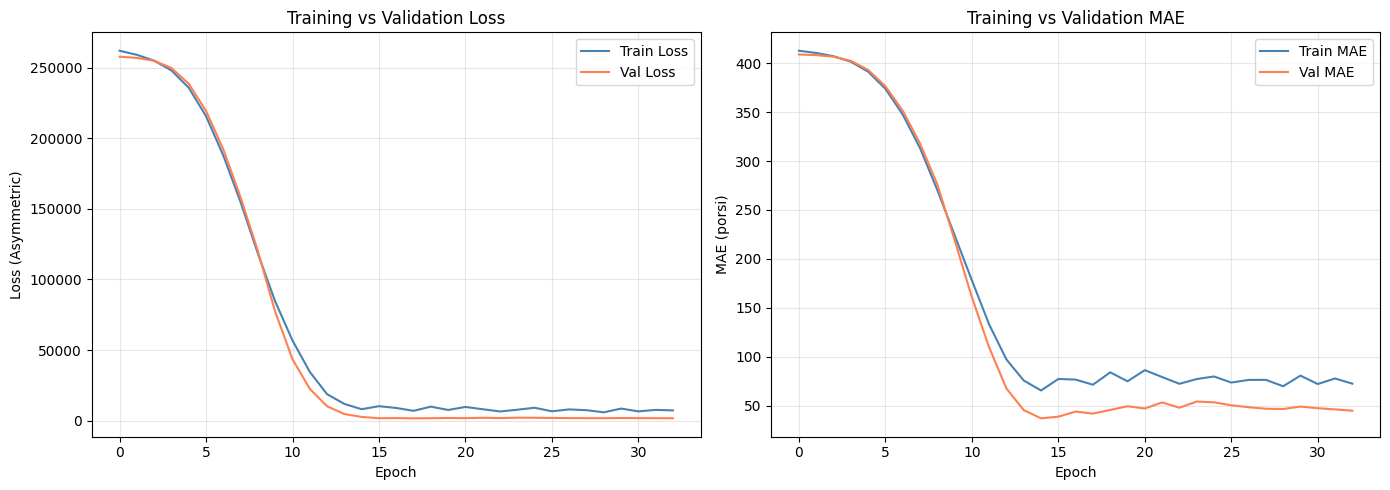

✅ Grafik disimpan: training_history.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='coral')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Asymmetric)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot MAE
axes[1].plot(history.history['mae'], label='Train MAE', color='steelblue')
axes[1].plot(history.history['val_mae'], label='Val MAE', color='coral')
axes[1].set_title('Training vs Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (porsi)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik disimpan: training_history.png')

## STEP 9 — Evaluasi Model di Test Set

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
       HASIL EVALUASI (TEST SET)
  MAE  : 40.01 porsi
  RMSE : 49.72 porsi
  MAPE : 10.86%


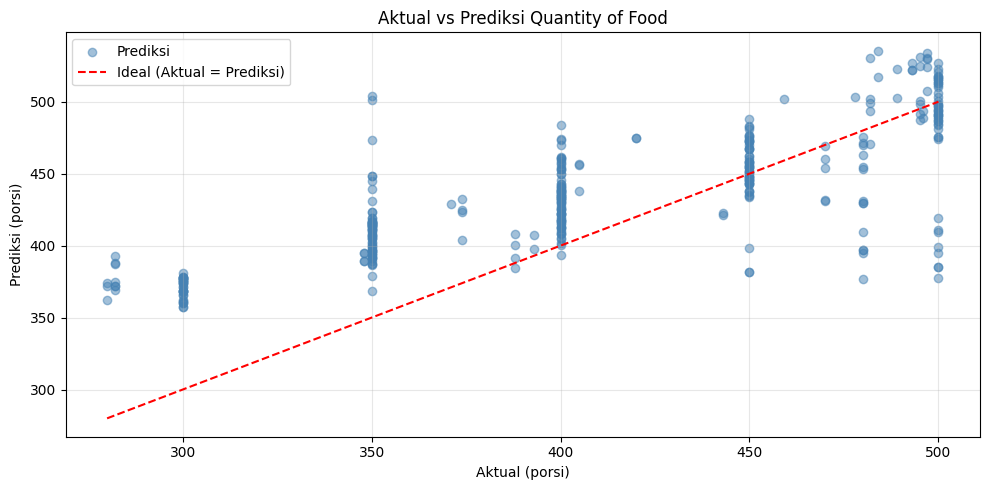

In [ ]:
y_pred = model.predict(X_test).flatten()

mae  = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print('HASIL EVALUASI (TEST SET)')
print(f'  MAE  : {mae:.2f} porsi')
print(f'  RMSE : {rmse:.2f} porsi')
print(f'  MAPE : {mape:.2f}%')

# Visualisasi Aktual vs Prediksi
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', label='Prediksi')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', label='Ideal (Aktual = Prediksi)')
plt.xlabel('Aktual (porsi)')
plt.ylabel('Prediksi (porsi)')
plt.title('Aktual vs Prediksi Quantity of Food')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 10 — Simpan Model & Artifacts

In [ ]:
model.save('food_waste_model.keras')

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler disimpan: scaler.pkl')

with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)
print('Encoders disimpan: encoders.pkl')

Scaler disimpan: scaler.pkl
Encoders disimpan: encoders.pkl


## STEP 11 — Inference Sederhana

Simulasi model dipakai untuk prediksi stok nyata.

Parameters:
- type_of_food        : 'Meat' / 'Vegetables' / 'Fruits' / 'Baked Goods' / 'Dairy Products'
- num_guests          : int (jumlah tamu)
- event_type          : 'Birthday' / 'Corporate' / 'Social Gathering' / 'Wedding'
- storage_conditions  : 'Refrigerated' / 'Room Temperature'
- seasonality         : 'All Seasons' / 'Summer' / 'Winter'
- preparation_method  : 'Buffet' / 'Finger Food' / 'Sit-down Dinner'
- wastage_food_amount : int (estimasi waste historis)

Returns:
- predicted_qty  : int   → stok optimal yang disarankan (porsi)
- waste_ratio    : float → persentase waste terhadap stok prediksi
- recommendation : str   → kategori rekomendasi
- detail         : str   → penjelasan lengkap untuk user

In [ ]:
def predict_optimal_stock(type_of_food, num_guests, event_type,
                           storage_conditions, seasonality,
                           preparation_method, wastage_food_amount):

    # Encode & scale input
    input_data = {
        'Type of Food'       : encoders['Type of Food'].transform([type_of_food])[0],
        'Number of Guests'   : num_guests,
        'Event Type'         : encoders['Event Type'].transform([event_type])[0],
        'Storage Conditions' : encoders['Storage Conditions'].transform([storage_conditions])[0],
        'Seasonality'        : encoders['Seasonality'].transform([seasonality])[0],
        'Preparation Method' : encoders['Preparation Method'].transform([preparation_method])[0],
        'Wastage Food Amount': wastage_food_amount
    }
    input_df      = pd.DataFrame([input_data])
    input_scaled  = scaler.transform(input_df)
    predicted     = model.predict(input_scaled, verbose=0)[0][0]
    predicted_qty = max(0, round(predicted))

    # waste ratio
    waste_ratio = (wastage_food_amount / predicted_qty) * 100

    # Rekomendasi berdasarkan waste ratio
    if waste_ratio > 15:
        recommendation = 'Waste ratio TINGGI — pertimbangkan kurangi order'
        detail = (f'Dari {predicted_qty} porsi yang disiapkan, sekitar {wastage_food_amount} porsi '
                  f'({waste_ratio:.1f}%) diprediksi terbuang. '
                  f'Coba kurangi stok atau ubah metode penyajian.')
    elif waste_ratio < 5:
        recommendation = 'Waste ratio RENDAH — stok sudah sangat efisien'
        detail = (f'Dari {predicted_qty} porsi yang disiapkan, hanya {wastage_food_amount} porsi '
                  f'({waste_ratio:.1f}%) yang diprediksi terbuang. '
                  f'Stok kamu sudah optimal!')
    else:
        recommendation = 'Waste ratio NORMAL — stok sudah efisien'
        detail = (f'Dari {predicted_qty} porsi yang disiapkan, sekitar {wastage_food_amount} porsi '
                  f'({waste_ratio:.1f}%) diprediksi terbuang. '
                  f'Masih dalam batas wajar, bisa tambah buffer 5% jika perlu.')

    return predicted_qty, waste_ratio, recommendation, detail


# Contoh penggunaan
qty, waste_ratio, rec, detail = predict_optimal_stock(
    type_of_food        = 'Vegetables',
    num_guests          = 450,
    event_type          = 'Birthday',
    storage_conditions  = 'Room Temperature',
    seasonality         = 'Summer',
    preparation_method  = 'Buffet',
    wastage_food_amount = 50
)

print('HASIL PREDIKSI')
print(f'Stok Optimal : {qty} porsi')
print(f'Waste Ratio  : {waste_ratio:.1f}%')
print(f'Rekomendasi  : {rec}')
print(f'Detail       : {detail}')

HASIL PREDIKSI
Stok Optimal : 512 porsi
Waste Ratio  : 9.8%
Rekomendasi  : Waste ratio NORMAL — stok sudah efisien
Detail       : Dari 512 porsi yang disiapkan, sekitar 50 porsi (9.8%) diprediksi terbuang. Masih dalam batas wajar, bisa tambah buffer 5% jika perlu.


In [ ]:
# Contoh beberapa skenario sekaligus
print('MULTI-SKENARIO PREDIKSI')

skenarios = [
    ('Vegetables',    450, 'Birthday',         'Room Temperature', 'Summer',      'Buffet',           50),
    ('Meat',          300, 'Wedding',           'Refrigerated',     'Summer',      'Buffet',           25),
    ('Baked Goods',   210, 'Corporate',         'Room Temperature', 'Winter',      'Finger Food',      15),
    ('Dairy Products',350, 'Social Gathering',  'Refrigerated',     'All Seasons', 'Sit-down Dinner',  60),
]
labels = ['Skenario 1', 'Skenario 2', 'Skenario 3', 'Skenario 4']

for label, (tf_, ng, et, sc, se, pm, wfa) in zip(labels, skenarios):
    qty, ratio, rec, detail = predict_optimal_stock(tf_, ng, et, sc, se, pm, wfa)
    print(f'\n🔹 {label}')
    print(f'   Input       : {ng} tamu | {tf_} | {et} | {pm} | waste historis {wfa}')
    print(f'   Stok Optimal: {qty} porsi')
    print(f'   Waste Ratio : {ratio:.1f}%')
    print(f'   Rekomendasi : {rec}')
    print(f'   Detail      : {detail}')

MULTI-SKENARIO PREDIKSI

🔹 Skenario 1
   Input       : 450 tamu | Vegetables | Birthday | Buffet | waste historis 50
   Stok Optimal: 512 porsi
   Waste Ratio : 9.8%
   Rekomendasi : Waste ratio NORMAL — stok sudah efisien
   Detail      : Dari 512 porsi yang disiapkan, sekitar 50 porsi (9.8%) diprediksi terbuang. Masih dalam batas wajar, bisa tambah buffer 5% jika perlu.

🔹 Skenario 2
   Input       : 300 tamu | Meat | Wedding | Buffet | waste historis 25
   Stok Optimal: 406 porsi
   Waste Ratio : 6.2%
   Rekomendasi : Waste ratio NORMAL — stok sudah efisien
   Detail      : Dari 406 porsi yang disiapkan, sekitar 25 porsi (6.2%) diprediksi terbuang. Masih dalam batas wajar, bisa tambah buffer 5% jika perlu.

🔹 Skenario 3
   Input       : 210 tamu | Baked Goods | Corporate | Finger Food | waste historis 15
   Stok Optimal: 368 porsi
   Waste Ratio : 4.1%
   Rekomendasi : Waste ratio RENDAH — stok sudah sangat efisien
   Detail      : Dari 368 porsi yang disiapkan, hanya 15 porsi (4.1%